In [26]:
import os
import re
from collections import defaultdict, Counter
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import polars as pl
import loguru as logger
import matplotlib
from tqdm import tqdm


from settings.settings_analyze_efizz import Settings_ae
from behave_analysis.process.session import get_experiment
from behave_analysis.utils.rayleigh.load_rayleigh import collect_all_rayleigh_paths, load_all_rayleigh_data
from behave_analysis.utils.rayleigh.manipulate_rayleigh_df import extract_compartment_values, extract_firing_rates
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe

from behave_analysis.analyze.stats.linshit import LinearShift
from behave_analysis.utils.PersistentPool import PersistentPool
from behave_analysis.analyze.TunED.stats import TunEDModelStats
from behave_analysis.analyze.TunED.tuning_curves import (
    ComputeObservedTuningFunction,
    ComputeNullHypothesisTuningFunction,
)
from behave_analysis.utils.creating_directories import make_directory
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe
from behave_analysis.analyze.TunED.tuned_load_sig_clusters import ReturnSigClusters


import os, re, pickle
from collections import Counter
from loguru import logger

# -------------------------- your imports / objects (kept minimal) -------------------------------
from settings.settings_analyze_efizz import Settings_ae as Settings
from behave_analysis.process.session import get_experiment
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe


from settings.settings_analyze_efizz import Settings_ae as Settings

from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

tinny_barrier = [JAL8_tiny_3may, JAL8_21may, JAL7_30apr]

# Mice groups based on session names
mice_groups = {
    "JAL6": ['JAL6_flip7_1apr', 'JAL6_flip3_18mar', 'JAL6_flip4_21mar', 'JAL6_flip5_25mar', 'JAL6_28mar'],
    "JAL3": ['JAL3_25aug', 'JAL3_1sept', 'JAL3_4sept', 'JAL3_7sept'],
    "JAL7": ['JAL7_sesh8_9apr', 'JAL7_sesh9_16apr', 'JAL7_flip5_22mar', 'JAL7_flip2_12mar', 'JAL7_23apr'],
    "JAL8": ['JAL8_flip1_25apr', 'JAL8_flip2_29apr', 'JAL8_flip4_10may', 'JAL8_14may'],
    "JAL4": ['JAL4_3rdSept', 'JAL4_19thSept', 'JAL4_28aug', 'JAL4_11thSept'],
    "JAL5": ['JAL005_8thSept', 'JAL005_21stSept']}


session_NAMES = ["JAL6_flip7_1apr", "JAL6_flip3_18mar", "JAL6_flip4_21mar", "JAL6_flip5_25mar", "JAL6_28mar",
                 "JAL3_25aug", "JAL3_1sept", "JAL3_4sept", "JAL3_7sept", 
                 "JAL005_8thSept", "JAL005_21stSept",
                 "JAL7_sesh8_9apr", "JAL7_sesh9_16apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_23apr",
                 "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip4_10may", "JAL8_14may",
                 "JAL4_3rdSept", "JAL4_19thSept", "JAL4_28aug", "JAL4_11thSept"]

def regex(angle):
    "Remove unwanted characters from angle file string"
    pattern = r'^(.*?)(?=_Rayleigh)'
    match = re.search(pattern, angle)
    assert match, f"Could not find match for {angle}"
    return match.group(0)

def nest_dic():
    """A function to create arbitrarily nested dictionaries"""
    return defaultdict(nest_dic)

# Init Params
conditions = ["barrier_pre_flip", "barrier_post_flip"]
dir = make_directory(r"Z:\Jasmine_Laurence\rayleigh_analysis")
angle_keys = ['hdir_Rayleigh.arrow', 'hsa_Rayleigh.arrow', 'h_postflipbar_a_Rayleigh.arrow', 'h_preflipbar_a_Rayleigh.arrow']

# Build the dictionary of meta data and top rayleighs per cell and session for tuned

In [ ]:
def build_threat_dict_max_rayleigh(
    experiments_objects,
    session_names,
    conditions,
    angle_keys,
    rayleigh_threshold=0.25,
    fr_threshold=2.0,
):
    """
    Recreates your per-session sweep loop as a function (no global state).
    Returns:
        threat_dict_max_rayleigh : dict[session_name][cluster_id][condition] -> [(angle,label_rayleigh), (angle,label_rayleigh)] | "Not tuned"
        stats : dict with {'not_meet_threshold': int, 'cell_count': int, 'skipped_sessions': list}
    Assumes the following helper functions/objects exist in scope:
        - get_experiment(session)
        - collect_all_rayleigh_paths(session, cluster_type="good", conditions=...)
        - load_all_rayleigh_data(paths)
        - extract_firing_rates(condition_data[cond][angle])
        - extract_compartment_values(condition_data[cond][angle], column_name="Rayleigh")
        - regex(angle)
        - Each loaded_session has attributes: base_path, processed_path
    """

    threat_dict_max_rayleigh = nest_dic()  # dict[session][cell][condition] = {max_rayleigh_angle}
    not_meet_threshold = 0
    cell_count = 0
    skipped_sessions = []

    for i, session in enumerate(experiments_objects):
        print(f"Processing session {i+1}/{len(experiments_objects)}: {session}")
        loaded_session = get_experiment(session)
        paths = collect_all_rayleigh_paths(session=loaded_session, cluster_type="good", conditions=conditions)  # paths[condition][angles]
        condition_data = load_all_rayleigh_data(paths)  # condition_data[condition][angles]

        # Load cluster master
        try:
            cluster_master = pd.read_csv(
                os.path.join(loaded_session.base_path, loaded_session.processed_path, "spike_count_by_frame_and_goodcluster.csv")
            )
        except Exception:
            print(f"Could not load cluster master for session {session}")
            skipped_sessions.append(session)
            continue

        spike_clusters = sorted(cluster_master['spike_clusters'].unique())

        # If no data for shelter_only, skip
        if len(condition_data["shelter_only"].keys()) == 0:
            print(f"Skipping session {session} as no data found")
            skipped_sessions.append(session)
            continue

        # Cells are same across conditions/angles in a session
        nCells = len(condition_data["shelter_only"]["hdir_Rayleigh.arrow"]["Rayleigh"])
        assert nCells == len(spike_clusters), f"Number of cells {nCells} does not match number of clusters {len(spike_clusters)}"
        cell_count += nCells

        for cell in range(nCells):
            tuned_across_conditions = False

            for ci, condition in enumerate(condition_data.keys()):
                rayleigh_list = []
                angle_list = []
                tuned = False  # tuned to any angle in this condition
                rayleigh = 0   # per-condition max Rayleigh

                for angle in angle_keys:
                    sz_fr, tz_fr = extract_firing_rates(condition_data[condition][angle])
                    cell_fr = tz_fr[cell]  # threat-zone firing rate only

                    # Extract Rayleigh (threat-only) for this angle
                    output = extract_compartment_values(condition_data[condition][angle], column_name="Rayleigh")

                    if (
                        (output[cell][1] > rayleigh)             # larger than current max
                        and (output[cell][1] > rayleigh_threshold) # above Rayleigh threshold
                        and (max(cell_fr) > fr_threshold)          # above FR threshold
                    ):
                        rayleigh = output[cell][1]
                        tuned = True
                        tuned_across_conditions = True

                    if output[cell][1] > rayleigh_threshold:
                        rayleigh_list.append(output[cell][1])
                        angle_list.append(regex(angle))

                # Top two Rayleighs (by threshold-filtered list)
                top_indices = np.argsort(rayleigh_list)[-2:]   # indices of two largest values
                top_angles = [angle_list[idx] for idx in top_indices]

                # Save per-cell, per-condition result
                sess_name = session_names[i]
                
                # iF there are more than 2 tuned angles, save the top 2 so we can run tuned on these two later
                if len(rayleigh_list) >= 2:
                    threat_dict_max_rayleigh[sess_name][spike_clusters[cell]][condition] = [
                        (top_angles[0], rayleigh_list[top_indices[0]]),
                        (top_angles[1], rayleigh_list[top_indices[1]]),
                    ]
                else:
                    threat_dict_max_rayleigh[sess_name][spike_clusters[cell]][condition] = "Not tuned"

            if not tuned_across_conditions:
                not_meet_threshold += 1

    stats = {
        "not_meet_threshold": not_meet_threshold,
        "cell_count": cell_count,
        "skipped_sessions": skipped_sessions,
    }

    # Save the threat dict as a pickle file
    with open(os.path.join(dir, "top_2_rayleigh_meta_data_for_tuned.pkl"), "wb") as f:
        pickle.dump(threat_dict_max_rayleigh, f)
    
    return threat_dict_max_rayleigh, stats

In [ ]:
# dict, stats = build_threat_dict_max_rayleigh(
#     experiments_objects,
#     session_NAMES,
#     conditions,
#     angle_keys,
#     rayleigh_threshold=0.25,
#     fr_threshold=2.0,
# )

# Tuned Model Code

In [22]:
class TunEdModelMod:
    """Conditional indepedence test"""

    def __init__(self, video_spike_count_df, session, cluster_type, conditions):
        self.spike_threshold = 1000  # If a cluster has less than this number of spikes it will be skipped
        self.session = session
        self.video_spike_count_df = video_spike_count_df
        self.cluster_type = cluster_type
        self.conditions = conditions

    def main(self, rayleigh_data):
        """Returns the classification results for each cluster and plots the tuning functions
        for each cluster and condition if requested"""
        classification_results = self.class_ec_clu_lin_shit(rayleigh_data)
        return classification_results

    def run_model_4_plots(self):
        """Run TunEd across clu and condition for plotting"""
        df = self.video_spike_count_df  # shorten name
        clean_spike_df = df.filter((df["OutofshelterIdx"] == True)) # Remove time mouse is in the shelter

        # Loop through every signle cluster
        for cluster in np.unique(clean_spike_df["spike_clusters"]):
            cluster_data = clean_spike_df.filter(pl.col("spike_clusters") == cluster)

            # For each condition
            for con_idx, condition in enumerate(self.conditions):
                filtered_df = filter_video_dataframe(dataframe=cluster_data, condition=condition)
                Nsamples, Nbins, hdir, hsa, raster = self.init_model_inputs(filtered_df)

                if self.skip_cluster_if_dud(cluster=cluster, cluster_df=filtered_df, spike_thres=self.spike_threshold):
                    continue

                # Compute mean firing curves
                hdir_tf_obj, hsa_tf_obj = self.compute_mean_firing_curves(raster, hdir, hsa, Nbins, Nsamples)

                # If any of the bins are empty skip this cluster
                if self.check_if_any_bins_are_empty(hdir_tf_obj, hsa_tf_obj):
                    continue

                # compute null hypotheses
                Pv1_v2, Pv2_v1 = self.compute_conditionals(hdir, hsa, hdir_tf_obj, hsa_tf_obj, Nbins)
                hdir_NH_object, hsa_NH_object = self.compute_NH_tuning(hdir_tf_obj, hsa_tf_obj, Pv1_v2, Pv2_v1)

                # Compute CIs
                hdir_CI, hsa_CI = self.produce_CIs(Nbins, hdir_tf_obj, hsa_NH_object, hsa_tf_obj, hdir_NH_object)

                self.plot_tuning_functions(
                    condition_indx=con_idx,
                    hdir_tf_obj=hdir_tf_obj,
                    hsa_NH_object=hsa_NH_object,
                    hsa_tf_obj=hsa_tf_obj,
                    hdir_NH_object=hdir_NH_object,
                    hdirCI=hdir_CI,
                    hsaCI=hsa_CI,
                )

            # Save and show if required
            plt.tight_layout()
            path = str(self.directory_location) + "\\" + f"cluster_{cluster}.png"
            plt.savefig(path)
      
    def skip_cluster_if_dud(self, cluster: int, cluster_df: pl.DataFrame, spike_thres: int) -> None:
        """Don't use clusters with no spikes or less than 2k spikes in model"""
        if len(cluster_df) == 0:
            logger.error(f"Cluster {cluster} has no spikes")
            return 1
        if len(cluster_df) < spike_thres:
            logger.error(f"Cluster {cluster} has less than {spike_thres} spikes, cut")
            return 1

    def class_ec_clu_lin_shit(self, rayleigh_data):
        """Classification of each cluster using linear shift combined with TunED

        Theory: Given a cell tuned to a single stimuli, shifting that stimuli
        should result in a significant change.Shifting the other stimuli the
        cell is NOT tuned to, should not result in a significant change.

        Returns:
        -- classification (dict): key is cluster and value is a dictionary of the
        classification results e.g =
        {"Hdir_tuned": True, "hsa_tuned": False, "mixed_tuning": False}
        """
        assert rayleigh_data is not None, "Rayleigh data must be provided"
        
        if 0:
            pool = PersistentPool(workers = 4) # pool for when we figure out the engineering problem
        else:
            pool = 'no' # doesn't use parallel computing

        # Remove time mouse is in the shelter
        df = self.video_spike_count_df  # shorten name
        clean_spike_df = df.filter((df["OutofshelterIdx"] == True))
        clusters = np.unique(clean_spike_df["spike_clusters"])
        shifted_variables = ["h_preflipbar_a", "h_postflipbar_a"]
        classification = {}

        for i, cluster in enumerate(tqdm(clusters, desc="Genereating null distribution for linear shift per cluster")):
            
            cell_data = rayleigh_data
            
            
            # Initalise vars required 4 classification results
            reject_hsa_nh = False
            reject_hdir_nh = False
            hdir_cell = False
            hsa_cell = False
            mixed_cell = False

            # Filter and remove dud clusters because they cause issues
            x = clean_spike_df.filter(pl.col("spike_clusters") == cluster)
            if self.skip_cluster_if_dud(cluster=cluster, cluster_df=x, spike_thres=self.spike_threshold):
                continue

            for shift_var in shifted_variables:
                
                filter_shift_var = shift_var + "_Rayleigh.arrow"
                
                # Filter cells to meet threshold
                filt = cell_data[filter_shift_var]
                
                try:
                    rayleigh_out = extract_compartment_values(filt, column_name="Rayleigh")
                    _, tz_fr = extract_firing_rates(filt)
                except Exception as e:
                    logger.error(f"Could not extract rayleigh or firing rates for cluster {cluster} with error {e}")
                    continue
                
                try:
                    # Check rayleigh threshold is met
                    if not (rayleigh_out[i][1] > 0.25):
                        continue # skip this cell
                    # Check firing rate threshold is met
                    if not (max(tz_fr[i]) > 2.0):
                        continue # skip this cell
                except Exception as e:
                    logger.error(f"Could not apply thresholds for cluster {cluster} with error {e}")
                    continue
                    
                # Compute the null distribution for each shifted variable
                result = LinearShift(
                    X=x,
                    y=x[shift_var],
                    stat_computation_func=self.user_defined_func_lin_shit,
                    size_of_central_chunk=int(len(x) / 3),
                    PPool = pool, 
                )

                # Reject or accept the null hypotheses
                if shift_var == "h_preflipbar_a":
                    reject_hsa_nh = result.reject_null

                elif shift_var == "h_postflipbar_a":
                    reject_hdir_nh = result.reject_null

            # Classification logic
            if reject_hsa_nh and not reject_hdir_nh:
                logger.info(f"Cluster number: {cluster} is tuned to h_preflipbar_a")
                hdir_cell = True

            elif not reject_hsa_nh and reject_hdir_nh:
                logger.info(f"Cluster number: {cluster} is tuned to h_postflipbar_a")
                hsa_cell = True

            elif reject_hsa_nh and reject_hdir_nh:
                logger.info(f"Cluster number: {cluster} has mixed selectivity")
                mixed_cell = True

            classification[cluster] = {"preflip_tuned": hdir_cell, "postflip_tuned": hsa_cell, "mixed_tuning": mixed_cell}

        return classification

    def user_defined_func_lin_shit(self, X, y):
        """The func passed to the lin shift class"""
        # Prepare data
        filtered_df = X
        filtered_df = filtered_df.with_columns(y)  # Replace the NH column with the shifted NH column
        
        Nsamples = len(filtered_df)
        Nbins = 20  # Number of bins to use to bin up the stimulus variable
        hdir = np.array(filtered_df["h_preflipbar_a"].to_numpy()).reshape(1, Nsamples)
        hsa = np.array(filtered_df["h_postflipbar_a"].to_numpy()).reshape(1, Nsamples)
        raster = np.array(filtered_df["spike_count"].to_numpy()).reshape(1, Nsamples)

        # Compute observed tuning functions
        hdir_tf_obj = ComputeObservedTuningFunction(
            spike_count_matrix=raster, stimulus_variable=hdir, Nbins=Nbins, Nsamples=Nsamples
        )
        hsa_tf_obj = ComputeObservedTuningFunction(
            spike_count_matrix=raster, stimulus_variable=hsa, Nbins=Nbins, Nsamples=Nsamples
        )

        # Compute probabilities
        jointProb_stimuli, _, _ = TunEDModelStats.compute_joint_prob(
            hdir,
            hsa,
            stimulusV2edges=hsa_tf_obj.stimulus_bin_edges,
            stimulusV1edges=hdir_tf_obj.stimulus_bin_edges,
            Nbins=Nbins,
        )
        Pv1, Pv2 = TunEDModelStats.compute_marginal_prob(jointProb_stimuli)
        Pv2_v1 = jointProb_stimuli / (np.ones(len(Pv2)).reshape(-1, 1) * Pv1)  # P(v2|v1)
        Pv1_v2 = jointProb_stimuli.T / (np.ones(len(Pv1)).reshape(-1, 1) * Pv2)  # P(v1|v2)

        # Compute NULL hypothesis that the driver is purely V1
        hdir_NH_object = ComputeNullHypothesisTuningFunction(
            observed_tuning_function=hdir_tf_obj.tuning_func,
            observed_tuning_function_s2=hdir_tf_obj.tuning_func_s2,
            num_values_for_Px=hsa_tf_obj.n,
            conditional_Py_x=Pv1_v2,
        )

        # Compute the NULL hypothesis that the driver is purely V2
        hsa_NH_object = ComputeNullHypothesisTuningFunction(
            observed_tuning_function=hsa_tf_obj.tuning_func,
            observed_tuning_function_s2=hsa_tf_obj.tuning_func_s2,
            num_values_for_Px=hdir_tf_obj.n,
            conditional_Py_x=Pv2_v1,
        )

        # Compute the significance of difference between the observed and expected tuning functions
        hdir_significance, _, _ = TunEDModelStats.compute_sig_between_curves(
            Nbins=Nbins,
            observed_tf=hdir_tf_obj.tuning_func,
            expected_tf=hsa_NH_object.tuning_func_nh,
            observed_sem=hdir_tf_obj.tuning_func_sem,
            expected_sem=hsa_NH_object.tuning_func_nh_sem,
        )

        hsa_significance, _, _ = TunEDModelStats.compute_sig_between_curves(
            Nbins=Nbins,
            observed_tf=hsa_tf_obj.tuning_func,
            expected_tf=hdir_NH_object.tuning_func_nh,
            observed_sem=hsa_tf_obj.tuning_func_sem,
            expected_sem=hdir_NH_object.tuning_func_nh_sem,
        )

        # If a cell is tuned to hdir, then shifting hdir will
        # result in a siginifcant change. And shifting hsa will
        # not result in a significant change because the cell
        # is not tuned to hsa. The opposite is true for hsa tuning.
        if y.name == "h_preflipbar_a":
            # Shift hdir, return HSA NH
            return np.sum(hdir_significance[0])

        elif y.name == "h_postflipbar_a":
            # Shift hsa, return HDIR NH
            return np.sum(hsa_significance[0])

    # ----------------------------- Helper functions to check data -----------------------------------

    def check_if_any_bins_are_empty(self, hdir_tf_obj, hsa_tf_obj) -> bool:
        """If bins are empty then skip the cluster, not sure if this is the best approach"""
        if hdir_tf_obj.skipCluster or hsa_tf_obj.skipCluster:
            logger.warning(
                "Skipping cluster as it has zero samples in one of the bins, this can be revisted but for now it is a conservative approach"
            )
            return True

    # ----------------------------- TunED model functions --------------------------------------------

    def init_model_inputs(self, data_df):
        """Init the inputs for the model
        
        NOTE - I have renamed hdir and hsa to be barrier angles"""
        n_samples = len(data_df)
        n_bins = 20  # Number of bins to use to bin up the stimulus variable
        hdir = np.array(data_df["h_preflipbar_a"].to_numpy()).reshape(1, n_samples)
        hsa = np.array(data_df["h_postflipbar_a"].to_numpy()).reshape(1, n_samples)
        raster = np.array(data_df["spike_count"].to_numpy()).reshape(1, n_samples)
        return n_samples, n_bins, hdir, hsa, raster

    def compute_mean_firing_curves(self, raster, hdir, hsa, Nbins, Nsamples):
        """Compute the mean firing curves for hdir and hsa"""
        hdir_tf_obj = ComputeObservedTuningFunction(
            spike_count_matrix=raster, stimulus_variable=hdir, Nbins=Nbins, Nsamples=Nsamples
        )
        hsa_tf_obj = ComputeObservedTuningFunction(
            spike_count_matrix=raster, stimulus_variable=hsa, Nbins=Nbins, Nsamples=Nsamples
        )
        return hdir_tf_obj, hsa_tf_obj

    def compute_conditionals(self, hdir, hsa, hdir_tf_obj, hsa_tf_obj, Nbins):
        """Compute the conditional probabilities"""
        joint_prob, _, _ = TunEDModelStats.compute_joint_prob(
            hdir,
            hsa,
            stimulusV2edges=hsa_tf_obj.stimulus_bin_edges,
            stimulusV1edges=hdir_tf_obj.stimulus_bin_edges,
            Nbins=Nbins,
        )
        Pv1, Pv2 = TunEDModelStats.compute_marginal_prob(joint_prob)
        Pv2_v1 = joint_prob / (np.ones(len(Pv2)).reshape(-1, 1) * Pv1)
        Pv1_v2 = joint_prob.T / (np.ones(len(Pv1)).reshape(-1, 1) * Pv2)  # P(v1|v2)
        return Pv1_v2, Pv2_v1

    def compute_NH_tuning(self, hdir_tf_obj, hsa_tf_obj, Pv1_v2, Pv2_v1):
        """Compute the NH tuning curves"""
        # Compute the NULL hypothesis that the driver is purely V1
        hdir_NH_object = ComputeNullHypothesisTuningFunction(
            observed_tuning_function=hdir_tf_obj.tuning_func,
            observed_tuning_function_s2=hdir_tf_obj.tuning_func_s2,
            num_values_for_Px=hsa_tf_obj.n,
            conditional_Py_x=Pv1_v2,
        )

        # Compute the NULL hypothesis that the driver is purely V2
        hsa_NH_object = ComputeNullHypothesisTuningFunction(
            observed_tuning_function=hsa_tf_obj.tuning_func,
            observed_tuning_function_s2=hsa_tf_obj.tuning_func_s2,
            num_values_for_Px=hdir_tf_obj.n,
            conditional_Py_x=Pv2_v1,
        )
        return hdir_NH_object, hsa_NH_object

    # ----------------------------- Produce confidence intervals for plotting ------------------------
    def convert_CIs_to_dict(self, hdirObservedCI, hdirExpectedCI, hsaObservedCI, hsaExpectedCI):
        """Convert confidence intervals to a dictionary"""
        hdir_ci = {"observedCI": hdirObservedCI, "expectedCI": hdirExpectedCI}  # Needed to plot MOE on tuning functions
        hsa_ci = {"observedCI": hsaObservedCI, "expectedCI": hsaExpectedCI}
        return hdir_ci, hsa_ci

    def produce_CIs(self, Nbins, hdir_tf_obj, hsa_NH_object, hsa_tf_obj, hdir_NH_object):
        """Produce CIs for each curve"""
        (
            _,
            hdirObservedCI,
            hdirExpectedCI,
        ) = TunEDModelStats.compute_sig_between_curves(
            Nbins=Nbins,
            observed_tf=hdir_tf_obj.tuning_func,
            expected_tf=hsa_NH_object.tuning_func_nh,
            observed_sem=hdir_tf_obj.tuning_func_sem,
            expected_sem=hsa_NH_object.tuning_func_nh_sem,
        )
        (
            _,
            hsaObservedCI,
            hsaExpectedCI,
        ) = TunEDModelStats.compute_sig_between_curves(
            Nbins=Nbins,
            observed_tf=hsa_tf_obj.tuning_func,
            expected_tf=hdir_NH_object.tuning_func_nh,
            observed_sem=hsa_tf_obj.tuning_func_sem,
            expected_sem=hdir_NH_object.tuning_func_nh_sem,
        )
        hdir_CI, hsa_CI = self.convert_CIs_to_dict(hdirObservedCI, hdirExpectedCI, hsaObservedCI, hsaExpectedCI)

        return hdir_CI, hsa_CI

    # ------------------------------- Utility functions ----------------------------------------------

    def save_classification_results(self, results) -> None:
        """Save the classification results to a pickle file"""
        file_obj = open(os.path.join(self.directory_location, "classification_results"), "wb")
        pickle.dump(results, file_obj)
        file_obj.close()

# I didn't filter on the threat zone, so the below data and code here in all Arena

you actuqlly dont ened to load the top 2 i did this before i realised the tune code wouldnt permit that so no arg is actually needed because we just only look at open and closed tunning hard coded

this takes 648 minutes

In [ ]:
conditions = ["barrier_pre_flip", "barrier_post_flip"]
SAVE_ROOT = r"Z:\Jasmine_Laurence\rayleigh_analysis\Top2_TunED"

def run_tuned_using_dict():
    final_results = defaultdict(dict)

    # Loop through each session
    for i, sesh in enumerate(experiments_objects):
        session_name = session_NAMES[i]
        logger.info(f"=== Session: {session_name} ===")
        exp = get_experiment(sesh)
        
        # Get the video and spike data
        try:
            video_and_spike_data_path = os.path.join(exp.base_path, exp.processed_path, "good_video_spike_count_df.parquet")
            df_all = pl.read_parquet(video_and_spike_data_path)
        except Exception as e:
            logger.warning(f"[{session_name}] could not find good_video_spike_count_df.parquet, skipping")
            print(e)
            continue

        for con in conditions:
            print(f"--- Condition: {con} ---")

            # subset to this cell + condition
            con_df = filter_video_dataframe(dataframe=df_all, condition=con)

            # run TunED
            model = TunEdModelMod(
                video_spike_count_df=con_df,
                session=session_name,
                cluster_type="good",
                conditions=[con],
            )
            
            classifcation_results = model.main()
            print(classifcation_results)
            final_results[session_name][con] = classifcation_results
    return final_results

final_results = run_tuned_using_dict()

# load the results, tuned classsifcation results threatzone filters on the threat zone compartment but no rayleigh or FR thresholding

In [23]:
# Load the final results
SAVE_ROOT = r"Z:\Jasmine_Laurence\rayleigh_analysis\Top2_TunED"
with open(os.path.join(SAVE_ROOT, "tuned_classification_results.pkl"), "rb") as f:
    final_results_whole_area_no_threshold = pickle.load(f)

# Plotting functions

In [30]:
def plot_pair_fractions_from_tuning_flags(final_results, save_path=None, title_suffix="", color_bars=None):
    """
    final_results structure expected:
        {session: {
            'barrier_pre_flip':  {cluster_id: {'preflip_tuned': bool, 'postflip_tuned': bool, 'mixed_tuning': bool}},
            'barrier_post_flip': {cluster_id: {'preflip_tuned': bool, 'postflip_tuned': bool, 'mixed_tuning': bool}},
        }}
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
    from scipy.stats import wilcoxon

    target_conditions = ["barrier_pre_flip", "barrier_post_flip"]

    # 1) Aggregate counts per session/condition using the actual structure
    rows = []
    for session, by_condition in final_results.items():
        for cond in target_conditions:
            clusters_map = by_condition.get(cond, {}) or {}
            if not isinstance(clusters_map, dict):
                # if data is malformed, skip gracefully
                continue

            total = len(clusters_map)
            open_n = closed_n = mixed_n = 0

            for _, flags in clusters_map.items():
                preflip  = bool(flags.get("preflip_tuned", False))
                postflip = bool(flags.get("postflip_tuned", False))
                mixed    = bool(flags.get("mixed_tuning", False))

                if cond == "barrier_pre_flip":
                    if preflip:  open_n  += 1
                    if postflip: closed_n += 1
                else:  # barrier_post_flip
                    if preflip:  closed_n += 1
                    if postflip: open_n  += 1

                if mixed:
                    mixed_n += 1

            if total == 0:
                continue

            rows.append({
                "session": session,
                "condition": cond,
                "total_cells": total,
                "open_edge_count": open_n,
                "closed_edge_count": closed_n,
                "mixed_count": mixed_n,
                "pct_open_over_total":   open_n / total,
                "pct_closed_over_total": closed_n / total,
                "pct_mixed_over_total":  mixed_n / total,
            })

    session_summary_df = pd.DataFrame(rows)
    if session_summary_df.empty:
        print("No data to plot: session_summary_df is empty. Check final_results content.")
        return session_summary_df, np.nan, np.nan

    # 2) Group means (unweighted across sessions)
    def mean0(s): return float(s.mean()) if len(s) else 0.0
    pre_open_mean   = mean0(session_summary_df.query("condition=='barrier_pre_flip'")["pct_open_over_total"])
    pre_closed_mean = mean0(session_summary_df.query("condition=='barrier_pre_flip'")["pct_closed_over_total"])
    post_open_mean  = mean0(session_summary_df.query("condition=='barrier_post_flip'")["pct_open_over_total"])
    post_closed_mean= mean0(session_summary_df.query("condition=='barrier_post_flip'")["pct_closed_over_total"])

    pre_mixed_mean  = mean0(session_summary_df.query("condition=='barrier_pre_flip'")["pct_mixed_over_total"])
    post_mixed_mean = mean0(session_summary_df.query("condition=='barrier_post_flip'")["pct_mixed_over_total"])

    bar_means = [pre_open_mean, pre_closed_mean, post_closed_mean, post_open_mean]
    x_labels = [
        'Open Edge | Pre flip condition',
        'Closed Edge | Pre flip condition',
        'Closed Edge | Post flip condition',
        'Open Edge | Post flip condition'
    ]
    x = np.arange(4)

    # 3) Paired per-session values and scatter
    rng = np.random.default_rng(7)
    open_pre_vals, closed_pre_vals = [], []
    open_post_vals, closed_post_vals = [], []
    all_session_vals = []

    fig, ax = plt.subplots(figsize=(10, 6))
    if color_bars is None:
        ax.bar(x, bar_means, alpha=0.85, color="rebeccapurple")
    else:
        ax.bar(x, bar_means, alpha=0.85, color=color_bars)

    for session in session_summary_df["session"].unique():
        sub = session_summary_df[session_summary_df["session"] == session]

        def pull(cond, col):
            v = sub.loc[sub["condition"] == cond, col]
            return float(v.iloc[0]) if len(v) else np.nan

        y0 = pull("barrier_pre_flip",  "pct_open_over_total")
        y1 = pull("barrier_pre_flip",  "pct_closed_over_total")
        y2 = pull("barrier_post_flip", "pct_closed_over_total")
        y3 = pull("barrier_post_flip", "pct_open_over_total")

        xs = x + rng.normal(0, 0.02, size=4)
        ys = np.array([y0, y1, y2, y3], dtype=float)
        all_session_vals.extend(ys[np.isfinite(ys)].tolist())

        ax.scatter(xs, ys, marker='x', s=60, linewidths=1.5, color='gray', alpha=0.7)
        if np.isfinite(y0) and np.isfinite(y1):
            ax.plot([xs[0], xs[1]], [y0, y1], color='gray', alpha=0.4, linewidth=1.2)
            open_pre_vals.append(y0); closed_pre_vals.append(y1)
        if np.isfinite(y2) and np.isfinite(y3):
            ax.plot([xs[2], xs[3]], [y2, y3], color='gray', alpha=0.4, linewidth=1.2)
            closed_post_vals.append(y2); open_post_vals.append(y3)

    ax.plot([x[0], x[1]], [bar_means[0], bar_means[1]], color='black', linewidth=2.2)
    ax.plot([x[2], x[3]], [bar_means[2], bar_means[3]], color='black', linewidth=2.2)

    vals_for_limit = np.array(bar_means + all_session_vals, dtype=float)
    vals_for_limit = vals_for_limit[np.isfinite(vals_for_limit)]
    ymax = float(vals_for_limit.max()) if vals_for_limit.size else 0.05
    y_top = max(0.03, ymax * 1.35)
    if y_top > 0.25:
        y_top = min(y_top, 0.25)

    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_ylim(0, y_top)
    ax.set_yticks(np.linspace(0, y_top, 6 if y_top >= 0.05 else 5))

    ax.set_ylabel('Fraction of cells (%)', fontsize=13)
    subtitle = f"(Mixed: Pre={pre_mixed_mean*100:.1f}%, Post={post_mixed_mean*100:.1f}%)"
    ax.set_title(f'Highest tuning edge within threat zone {title_suffix}\n{subtitle}', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=15)
    ax.grid(axis='y', alpha=0.3)

    def p_val(a, b):
        a = np.asarray(a); b = np.asarray(b)
        if len(a) < 3 or len(a) != len(b):  # need paired sessions
            return np.nan
        if np.allclose(a, b):
            return 1.0
        return wilcoxon(a, b, zero_method='wilcox', alternative='two-sided', mode='auto')[1]

    p_pre  = p_val(open_pre_vals, closed_pre_vals)
    p_post = p_val(open_post_vals, closed_post_vals)

    def stars(p):
        if np.isnan(p): return "n/a"
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

    def add_sig_bar(ax, x1, x2, top_y, p, frac_pad):
        lab = stars(p)
        y = top_y + frac_pad
        ax.plot([x1, x1, x2, x2], [y, y+frac_pad*0.5, y+frac_pad*0.5, y], lw=1.5, color='k')
        ax.text((x1 + x2)/2, y + frac_pad*0.6, lab, ha='center', va='bottom', fontsize=11)

    pad = 0.04 * y_top
    add_sig_bar(ax, 0, 1, max(bar_means[0], bar_means[1]), p_pre,  pad)
    add_sig_bar(ax, 2, 3, max(bar_means[2], bar_means[3]), p_post, pad)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

    print("p (Open vs Closed, Pre-flip) :", p_pre)
    print("p (Open vs Closed, Post-flip):", p_post)

    return session_summary_df, p_pre, p_post

def plot_tuning_by_mouse(final_results, mice_groups, save_path=None, title_suffix=""):
    """
    Publication-style 2x3 grid (one per mouse) with per-session dots and paired significance.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
    from scipy.stats import wilcoxon

    # ---------- helpers ----------
    target_conditions = ["barrier_pre_flip", "barrier_post_flip"]

    def summarize_for_sessions(session_list):
        rows = []
        for session in session_list:
            by_condition = final_results.get(session, {})
            for cond in target_conditions:
                clusters_map = by_condition.get(cond, {}) or {}
                if not isinstance(clusters_map, dict):
                    continue
                total = len(clusters_map)
                if total == 0:
                    continue

                open_n = closed_n = mixed_n = 0
                for _, flags in clusters_map.items():
                    preflip  = bool(flags.get("preflip_tuned", False))
                    postflip = bool(flags.get("postflip_tuned", False))
                    mixed    = bool(flags.get("mixed_tuning", False))

                    if cond == "barrier_pre_flip":
                        if preflip:  open_n  += 1
                        if postflip: closed_n += 1
                    else:  # barrier_post_flip
                        if preflip:  closed_n += 1
                        if postflip: open_n  += 1

                    if mixed:
                        mixed_n += 1

                rows.append({
                    "session": session,
                    "condition": cond,
                    "total_cells": total,
                    "open_edge_count": open_n,
                    "closed_edge_count": closed_n,
                    "mixed_count": mixed_n,
                    "pct_open_over_total":   open_n / total,
                    "pct_closed_over_total": closed_n / total,
                    "pct_mixed_over_total":  mixed_n / total,
                })
        return pd.DataFrame(rows)

    def p_val(a, b):
        a = np.asarray(a); b = np.asarray(b)
        if len(a) < 3 or len(a) != len(b):
            return np.nan
        if np.allclose(a, b):
            return 1.0
        return wilcoxon(a, b, zero_method="wilcox", alternative="two-sided", mode="auto")[1]

    def stars(p):
        if np.isnan(p): return "n/a"
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return "ns"

    def add_sig_bar(ax, x1, x2, y_base, p, lift, color="k"):
        if np.isnan(p):
            return
        ax.plot([x1, x1, x2, x2], [y_base, y_base+lift, y_base+lift, y_base], lw=1.4, color=color)
        ax.text((x1+x2)/2, y_base+lift*1.05, stars(p), ha="center", va="bottom", fontsize=10, color=color)

    # ---------- data aggregation ----------
    mouse_names = ["JAL3", "JAL4", "JAL5", "JAL6", "JAL7", "JAL8"]  # preferred order

    per_mouse_df = {}
    all_vals = []
    for mouse in mouse_names:
        sessions = [s for s in mice_groups.get(mouse, []) if s in final_results]
        df = summarize_for_sessions(sessions)
        per_mouse_df[mouse] = df
        if not df.empty:
            all_vals.extend(df["pct_open_over_total"].tolist())
            all_vals.extend(df["pct_closed_over_total"].tolist())

    # Global y-limit with headroom for sig bars
    global_ymax = max(all_vals) if all_vals else 0.05
    y_top = min(max(0.08, global_ymax * 1.6), 0.35)  # some headroom, capped

    # ---------- figure ----------
    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.dpi": 120
    })

    fig, axes = plt.subplots(
        2, 3, figsize=(18, 8), sharey=True, constrained_layout=True
    )
    axes = axes.flatten()

    # plotting constants
    x = np.arange(4)
    bar_color = "#6b4aa5"  # deep purple
    sc_color = "dimgray"

    for i, mouse in enumerate(mouse_names):
        ax = axes[i]
        dfm = per_mouse_df.get(mouse)

        if dfm is None or dfm.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        def mean0(s): return float(s.mean()) if len(s) else 0.0
        pre_open_mean   = mean0(dfm.query("condition=='barrier_pre_flip'")["pct_open_over_total"])
        pre_closed_mean = mean0(dfm.query("condition=='barrier_pre_flip'")["pct_closed_over_total"])
        post_open_mean  = mean0(dfm.query("condition=='barrier_post_flip'")["pct_open_over_total"])
        post_closed_mean= mean0(dfm.query("condition=='barrier_post_flip'")["pct_closed_over_total"])
        pre_mixed_mean  = mean0(dfm.query("condition=='barrier_pre_flip'")["pct_mixed_over_total"])
        post_mixed_mean = mean0(dfm.query("condition=='barrier_post_flip'")["pct_mixed_over_total"])

        bar_means = [pre_open_mean, pre_closed_mean, post_closed_mean, post_open_mean]

        # Bars
        ax.bar(x, bar_means, color=bar_color, alpha=0.9, width=0.75, edgecolor="black", linewidth=0.5)

        # Session scatter + paired lines
        rng = np.random.default_rng(7)
        open_pre_vals, closed_pre_vals = [], []
        open_post_vals, closed_post_vals = [], []

        for session in dfm["session"].unique():
            sub = dfm[dfm["session"] == session]

            def pull(cond, col):
                v = sub.loc[sub["condition"] == cond, col]
                return float(v.iloc[0]) if len(v) else np.nan

            y0 = pull("barrier_pre_flip",  "pct_open_over_total")
            y1 = pull("barrier_pre_flip",  "pct_closed_over_total")
            y2 = pull("barrier_post_flip", "pct_closed_over_total")
            y3 = pull("barrier_post_flip", "pct_open_over_total")

            xs = x + rng.normal(0, 0.02, size=4)
            ys = np.array([y0, y1, y2, y3], dtype=float)

            ax.scatter(xs, ys, marker="x", s=55, color=sc_color, linewidths=1.2, alpha=0.8)
            if np.isfinite(y0) and np.isfinite(y1):
                ax.plot([xs[0], xs[1]], [y0, y1], color=sc_color, alpha=0.35, linewidth=1.1)
                open_pre_vals.append(y0); closed_pre_vals.append(y1)
            if np.isfinite(y2) and np.isfinite(y3):
                ax.plot([xs[2], xs[3]], [y2, y3], color=sc_color, alpha=0.35, linewidth=1.1)
                closed_post_vals.append(y2); open_post_vals.append(y3)

        # Cosmetics
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
        ax.set_ylim(0, y_top)
        ax.set_xticks(x)
        ax.set_xticklabels(["Open|Pre", "Closed|Pre", "Closed|Post", "Open|Post"], rotation=0)
        ax.grid(axis="y", alpha=0.25, linewidth=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Per-mouse significance bars on the plot
        p_pre  = p_val(open_pre_vals,  closed_pre_vals)
        p_post = p_val(open_post_vals, closed_post_vals)
        # lift relative to axis height
        lift = 0.05 * y_top
        add_sig_bar(ax, 0, 1, y_base=max(bar_means[0], bar_means[1]) + 0.012, p=p_pre,  lift=lift)
        add_sig_bar(ax, 2, 3, y_base=max(bar_means[2], bar_means[3]) + 0.012, p=p_post, lift=lift)

        ax.set_title(
            f"{mouse} (nSess={len(dfm['session'].unique())})\n"
            f"Mixed: pre {pre_mixed_mean*100:.1f}%, post {post_mixed_mean*100:.1f}%",
            pad=6
        )

    # Shared labels and title
    try:
        fig.supylabel("Fraction of cells (%)")
    except Exception:
        fig.text(0.005, 0.5, "Fraction of cells (%)", rotation="vertical", va="center", fontsize=12)
    fig.suptitle(f"Highest tuning edge within {title_suffix} by mouse", y=0.995, fontsize=14)

    if save_path:
        # Use vector formats for publication (PDF/EPS/SVG) if desired
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return per_mouse_df

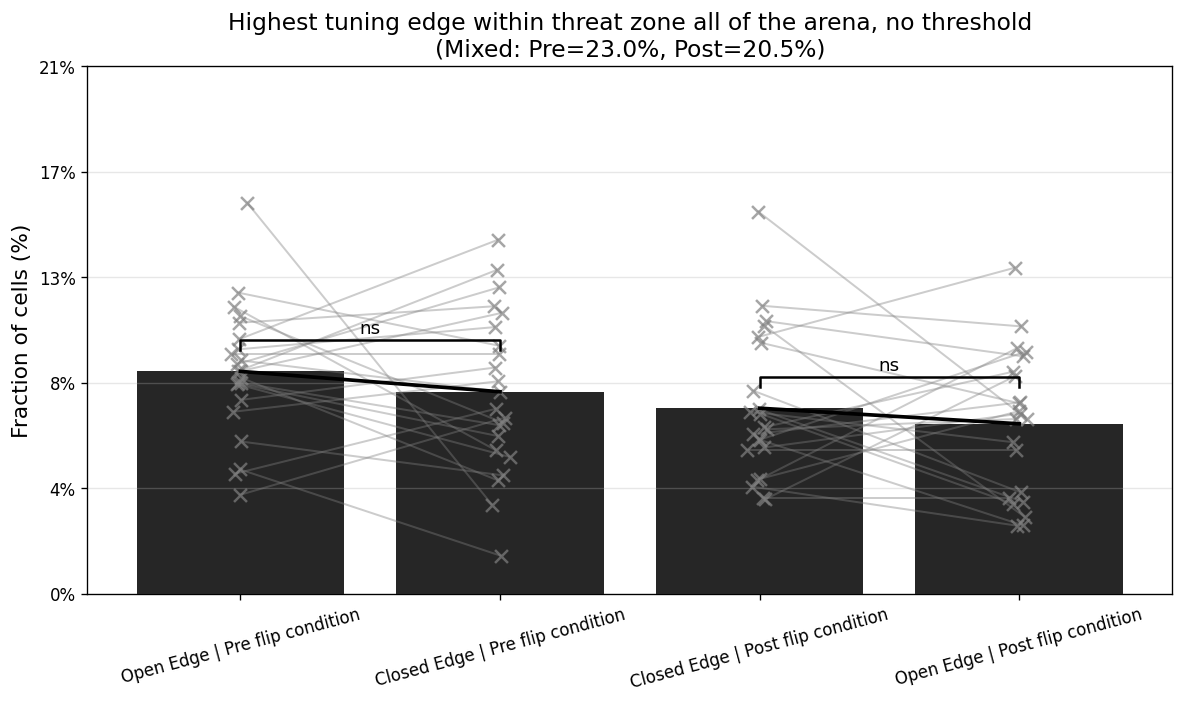

p (Open vs Closed, Pre-flip) : 0.4140400034242331
p (Open vs Closed, Post-flip): 0.5015913016269502


,session,condition,total_cells,mixed_count,pct_mixed_over_total
0,JAL6_flip7_1apr,barrier_pre_flip,257,43,0.167315
1,JAL6_flip7_1apr,barrier_post_flip,252,26,0.103175
2,JAL6_flip5_25mar,barrier_pre_flip,112,30,0.267857
3,JAL6_flip5_25mar,barrier_post_flip,113,32,0.283186
4,JAL6_28mar,barrier_pre_flip,123,45,0.365854


In [31]:
%matplotlib inline
# Your dict is named `final_results`
df, p_pre, p_post = plot_pair_fractions_from_tuning_flags(
    final_results_whole_area_no_threshold,
    save_path=None,           # e.g., "tuning_edge_percent_plot.eps"
    title_suffix="all of the arena, no threshold",
    color_bars="black"
)

# Inspect mixed-tuning per session/condition:
df.loc[:, ["session","condition","total_cells","mixed_count","pct_mixed_over_total"]].head()


In [ ]:
per_mouse_df = plot_tuning_by_mouse(final_results, mice_groups, save_path=None, title_suffix="")

# Now you've seen its not signifcant and got sad, run it with thresholding criteria

takes 450 minutes

In [ ]:
def run_tuned_using_dict_threat():
    final_results = defaultdict(dict)

    # Loop through each session
    for i, sesh in enumerate(experiments_objects):
        session_name = session_NAMES[i]
        logger.info(f"=== Session: {session_name} ===")
        exp = get_experiment(sesh)
        paths = collect_all_rayleigh_paths(session=exp, cluster_type="good", conditions=conditions)  # paths[condition][angles]
        condition_data = load_all_rayleigh_data(paths)  # condition_data[condition][angles]
        
        # Get the video and spike data
        try:
            video_and_spike_data_path = os.path.join(exp.base_path, exp.processed_path, "good_video_spike_count_df.parquet")
            df_all = pl.read_parquet(video_and_spike_data_path)
        except Exception as e:
            logger.warning(f"[{session_name}] could not find good_video_spike_count_df.parquet, skipping")
            print(e)
            continue
        
        # Filter to only threat zone data, assuming center is at 512 y pixels
        df_all = df_all.filter(
            pl.col("mouse_y_position").is_not_null() & (pl.col("mouse_y_position") < 512)
        )

        for con in conditions:
            print(f"--- Condition: {con} ---")
            
            # Filter rayleigh data
            rayleigh_data = condition_data[con]

            # subset to this cell + condition
            con_df = filter_video_dataframe(dataframe=df_all, condition=con)

            # run TunED
            model = TunEdModelMod(
                video_spike_count_df=con_df,
                session=session_name,
                cluster_type="good",
                conditions=[con],
            )
            classifcation_results = model.main(rayleigh_data=rayleigh_data)
            print(classifcation_results)
            final_results[session_name][con] = classifcation_results
    return final_results

final_results_with_threshold = run_tuned_using_dict_threat()
SAVE_ROOT = r"Z:\Jasmine_Laurence\rayleigh_analysis\Top2_TunED"
# with open(os.path.join(SAVE_ROOT, "tuned_classification_results_threatzone_filt_threshold.pkl"), "wb") as f:
#     pickle.dump(final_results_with_threshold, f)

"tuned_classification_results_threatzone_filt.pkl" file has no rayeligh threshold or fr threshold

In [32]:
# load the final results filtered to threat zone
with open(os.path.join(SAVE_ROOT, "tuned_classification_results_threatzone_filt_with_threshold.pkl"), "rb") as f:
    final_results_with_threshold = pickle.load(f)

EOFError: Ran out of input

In [ ]:
%matplotlib inline
per_mouse_df_hi = plot_tuning_by_mouse(final_results_with_threshold, mice_groups, save_path=None, title_suffix="")

In [ ]:
df, p_pre, p_post = plot_pair_fractions_from_tuning_flags(
    final_results_with_threshold,
    save_path=None,           # e.g., "tuning_edge_percent_plot.eps"
    title_suffix=""
)